# Music Recommender — End-to-End Pipeline
Complete pipeline: dataset extraction → user data → jSymbolic features → KG construction & enrichment → baselines → autoencoder → HGT recommender.  
Every major section checks for cached artefacts on disk before re-running expensive steps. Set `FORCE_REBUILD = True` to invalidate all caches.

In [1]:
from __future__ import annotations
import sys, os, warnings, importlib, re, json, subprocess, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# ── Data paths ─────────────────────────────────────────────────────────────────
RAW            = ROOT / "data" / "raw"
INTERIM        = ROOT / "data" / "interim"
PROCESSED      = ROOT / "data" / "processed"
FINAL          = ROOT / "data" / "final"
ONTOLOGY       = ROOT / "data" / "ontology"

# Evaluation / result artifacts — lightweight CSVs, plots, qualitative outputs
# (still inside data/ so they stay gitignored, but in a clean hierarchy)
FINAL_MODELS_DIR = FINAL / "models"
KNN_RESULTS_DIR  = FINAL_MODELS_DIR / "knn"
HGT_RESULTS_DIR  = FINAL_MODELS_DIR / "hgt"
AE_RESULTS_DIR   = FINAL_MODELS_DIR / "autoencoder"

# Model weights / checkpoints — live OUTSIDE data/, gitignored via models/*
# Use W&B artifacts as the source-of-truth for reproducibility.
MODELS_DIR     = ROOT / "models"
AE_WEIGHTS_DIR = MODELS_DIR / "autoencoder"
HGT_WEIGHTS_DIR= MODELS_DIR / "hgt"
KNN_CACHE_DIR  = MODELS_DIR / "knn"

for p in [INTERIM, PROCESSED, FINAL,
          KNN_RESULTS_DIR, HGT_RESULTS_DIR, AE_RESULTS_DIR,
          AE_WEIGHTS_DIR, HGT_WEIGHTS_DIR, KNN_CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── Artefact paths ─────────────────────────────────────────────────────────────
# Raw / interim data
LAKH_PQ            = PROCESSED / "lakh_msd_dataset.parquet"
TASTE_PQ           = PROCESSED / "taste_profile_filtered.parquet"
PER_USER_CSV       = PROCESSED / "taste_profile_per_user.csv"
PER_SONG_CSV       = PROCESSED / "taste_profile_per_song.csv"
INTERIM_CSV        = INTERIM   / "interim.csv"
KG_INPUT_PQ        = INTERIM   / "kg_input.parquet"
KG_TASTE_PQ        = INTERIM   / "kg_taste_profile.parquet"

# Ontology / KG outputs
ONTO_BASE          = ONTOLOGY  / "MusicRecSyst.ttl"
ONTO_OUT           = FINAL     / "MusicRecSyst_populated.ttl"
ONTO_OUT_SIMPLE    = FINAL     / "MusicRecSyst_populated_simple.ttl"
LISTENING_NT       = FINAL     / "MusicRecSyst_listening.nt"
LISTENING_NT_SIM   = FINAL     / "MusicRecSyst_listening_simple.nt"

# Autoencoder — weights in models/, embeddings (intermediate data) in interim/
AE_EMBEDDINGS_PQ   = INTERIM      / "ae_embeddings.parquet"
AE_MODEL_PATH      = AE_WEIGHTS_DIR / "ae_model.pt"

# KNN — neighbour cache (binary, large) in models/knn/; metrics in data/final/models/knn/
KNN_VAL_CSV        = KNN_RESULTS_DIR / "knn_cf_val_sweep_results.csv"
KNN_TEST_CSV       = KNN_RESULTS_DIR / "knn_cf_final_test_summary.csv"
KNN_NBRS_CACHE     = KNN_CACHE_DIR   / "knn_cf_val_sweep_results_nbrs.npz"
KNN_POP_CSV        = KNN_RESULTS_DIR / "knn_pop_metrics.csv"
KNN_POP_JSON       = KNN_RESULTS_DIR / "knn_pop_metrics.json"
KNN_VAL_PLOT_PNG   = KNN_RESULTS_DIR / "knn_val_sweep.png"
KFOLD_CSV          = KNN_RESULTS_DIR / "knn_cf_kfold_results.csv"
SPLIT_PQ           = PROCESSED       / "train_val_test_splits.parquet"
FINAL_SPLITS_DIR   = KNN_RESULTS_DIR

# HGT — weights + pickled result in models/hgt/; metrics/plots in data/final/models/hgt/
HGT_MODEL_PATH     = HGT_WEIGHTS_DIR / "hgt_model.pt"
HGT_RESULT_PATH    = HGT_WEIGHTS_DIR / "hgt_results.pkl"

# ── Global flags ───────────────────────────────────────────────────────────────
FORCE_REBUILD    = False   # set True to invalidate all file-based caches
FORCE_REBUILD_WD = False   # set True to re-query Wikidata (slow)
RUN_WIKIDATA     = True    # set False to skip Wikidata enrichment entirely
SKIP_DOWNLOAD    = True    # set False to re-download raw data from the internet
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

# ── W&B (Weights & Biases) — global project config ────────────────────────────
WANDB_PROJECT = "music-recommender-system"
WANDB_ENTITY  = None       # set to your W&B username/team, or leave None
WANDB_GROUP   = "KG-DL-PROJECT"  # groups all runs of this experiment family

print("ROOT              :", ROOT)
print("device            :", DEVICE)
print("FORCE_REBUILD     :", FORCE_REBUILD)
print(f"W&B project       : {WANDB_PROJECT}  (group={WANDB_GROUP})")
print("\nKey output directories:")
print(f"  model weights   → {MODELS_DIR.relative_to(ROOT)}/")
print(f"  eval artifacts  → {FINAL_MODELS_DIR.relative_to(ROOT)}/")


ROOT   : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project
device : cpu
FORCE_REBUILD: False
W&B project : music-recommender-system  (group=KG-DL-PROJECT)


## 1 — Dataset Extraction
Discovers Lakh MIDI ↔ MSD tracks, filters by DTW score ≥ 0.55, reads MSD HDF5 metadata, extracts MIDI instrumentation, deduplicates, and persists to `lakh_msd_dataset.parquet`.

In [2]:
from data.dataset_extraction import LakhMSDLinker, load_dataset

# ── 1.1 Download raw data (run once) ─────────────────────────────────────────
if not SKIP_DOWNLOAD:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "download_lmd.py"),
                    "--dest", str(RAW), "--skip-existing"], check=True)

# ── 1.2 Auto-detect paths from manifest ──────────────────────────────────────
_manifest = json.loads((RAW / "manifest.json").read_text()) if (RAW / "manifest.json").exists() else {}
MIDI_ROOT         = Path(_manifest.get("lmd_matched",    {}).get("unpacked", RAW / "lmd_matched"))
H5_ROOT           = Path(_manifest.get("lmd_matched_h5", {}).get("unpacked", RAW / "lmd_matched_h5"))
MATCH_SCORES_PATH = Path(_manifest.get("match_scores",   {}).get("archive",  RAW / "match_scores.json"))

for label, p in [("MIDI root", MIDI_ROOT), ("HDF5 root", H5_ROOT), ("match_scores", MATCH_SCORES_PATH)]:
    print(f"  {'✓' if p.exists() else '✗'}  {label}: {p}")

# ── 1.3 Build or load dataset ────────────────────────────────────────────────
if LAKH_PQ.exists() and not FORCE_REBUILD:
    lakh_df = load_dataset(LAKH_PQ)
    print(f"[SKIP] loaded lakh_msd from {LAKH_PQ}  shape={lakh_df.shape}")
else:
    linker = LakhMSDLinker(midi_root=MIDI_ROOT, h5_root=H5_ROOT,
                           match_scores_path=MATCH_SCORES_PATH,
                           min_score=0.55, pick_midi="best")
    lakh_df = linker.build_dataset(max_tracks=None, verbose=True, include_midi=True)
    lakh_df.to_parquet(LAKH_PQ, index=False)
    lakh_df[[ c for c in lakh_df.columns
              if not isinstance(lakh_df[c].iloc[0] if len(lakh_df) else None, list)
            ]].to_csv(LAKH_PQ.with_suffix(".csv"), index=False)
    print(f"saved → {LAKH_PQ}  shape={lakh_df.shape}")

print(f"Dataset: {len(lakh_df):,} tracks, {lakh_df.shape[1]} columns")

  ✓  MIDI root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  ✓  HDF5 root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  ✓  match_scores: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json
[SKIP] loaded lakh_msd from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/lakh_msd_dataset.parquet  shape=(19037, 40)
Dataset: 19,037 tracks, 40 columns


## 2 — User Data Integration
Downloads Echo Nest Taste Profile (train_triplets.txt), removes mismatch songs, intersects with LMD, cold-start filters (≥ 5 plays/user), saves filtered parquet.

In [3]:
from data.dataset_extraction import (
    load_taste_profile, load_sid_mismatches,
    filter_taste_profile, build_user_song_stats,
)

TRIPLETS_TXT = RAW / "train_triplets.txt"
MISMATCHES   = RAW / "sid_mismatches.txt"

# ── 2.1 Download (once) ──────────────────────────────────────────────────────
if not SKIP_DOWNLOAD:
    for target in ("triplets", "mismatches"):
        subprocess.run([sys.executable, str(ROOT / "scripts" / "download_user_data.py"),
                        "--dest", str(RAW), "--only", target], check=True)

# ── 2.2 Build or load ────────────────────────────────────────────────────────
if TASTE_PQ.exists() and PER_USER_CSV.exists() and PER_SONG_CSV.exists() and not FORCE_REBUILD:
    taste_df = pd.read_parquet(TASTE_PQ)
    print(f"[SKIP] loaded taste_profile from {TASTE_PQ}  shape={taste_df.shape}")
else:
    raw_triplets = load_taste_profile(TRIPLETS_TXT, chunksize=500_000, verbose=True)
    bad_song_ids = load_sid_mismatches(MISMATCHES, verbose=True)
    lmd_song_ids = set(lakh_df["song_id"].dropna().unique())
    taste_df = filter_taste_profile(raw_triplets, bad_song_ids=bad_song_ids,
                                    lmd_song_ids=lmd_song_ids, min_plays_per_user=5, verbose=True)
    stats_d = build_user_song_stats(taste_df, lmd_df=lakh_df)
    taste_df.to_parquet(TASTE_PQ, index=False)
    stats_d["per_user"].reset_index().to_csv(PER_USER_CSV, index=False)
    stats_d["per_song"].reset_index().to_csv(PER_SONG_CSV, index=False)
    print(f"saved → {TASTE_PQ}")

print(f"Taste profile: {len(taste_df):,} interactions  "
      f"users={taste_df['user_id'].nunique():,}  songs={taste_df['song_id'].nunique():,}")

[SKIP] loaded taste_profile from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/taste_profile_filtered.parquet  shape=(3048959, 3)
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227


## 3 — Music Feature Extraction (jSymbolic)
Only jSymbolic features were successfully extracted. `interim.csv` maps MIDI file paths → 519 numeric features. We load it and align song_ids via MIDI hash.

In [4]:
def _load_jsymbolic_with_song_ids(interim_csv: Path, lakh: pd.DataFrame) -> pd.DataFrame:
    """Load interim.csv, map MIDI hash → song_id, return features indexed by song_id."""
    raw = pd.read_csv(interim_csv)
    raw.rename(columns={raw.columns[0]: "raw_path"}, inplace=True)
    raw["midi_hash"] = raw["raw_path"].apply(
        lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
    )
    raw = raw.dropna(subset=["midi_hash"])
    lakh_lookup = (
        lakh[["midi_path", "song_id"]].copy()
        .assign(midi_hash=lambda d: d["midi_path"].apply(
            lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
        ))
        .dropna(subset=["midi_hash", "song_id"])
        .drop_duplicates("midi_hash")
    )
    merged = raw.merge(lakh_lookup[["midi_hash", "song_id"]], on="midi_hash", how="inner")
    feat_cols = [c for c in merged.columns if c not in ("raw_path", "midi_hash", "song_id")]
    result = merged[["song_id"] + feat_cols].drop_duplicates("song_id").set_index("song_id")
    return result.apply(pd.to_numeric, errors="coerce")

if not INTERIM_CSV.exists():
    raise FileNotFoundError(
        f"{INTERIM_CSV} not found. Run the jSymbolic extraction pipeline first "
        "(see notebooks/01_music_features_extraction.ipynb)."
    )

jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)
print(f"jSymbolic features: {jsym_df.shape[0]:,} songs × {jsym_df.shape[1]} features")
print(f"NaN rate: {jsym_df.isnull().mean().mean():.1%}")
jsym_df.head(2)

jSymbolic features: 7,013 songs × 1495 features
NaN rate: 0.0%


,Basic_Pitch_Histogram_0,Basic_Pitch_Histogram_1,Basic_Pitch_Histogram_2,Basic_Pitch_Histogram_3,Basic_Pitch_Histogram_4,Basic_Pitch_Histogram_5,Basic_Pitch_Histogram_6,Basic_Pitch_Histogram_7,Basic_Pitch_Histogram_8,Basic_Pitch_Histogram_9,...,Parallel_Motion,Similar_Motion,Contrary_Motion,Oblique_Motion,Parallel_Fifths,Parallel_Octaves,Dynamic_Range,Variation_of_Dynamics,Variation_of_Dynamics_In_Each_Voice,Average_Note_to_Note_Change_in_Dynamics
song_id,,,,,,,,,,,,,,,,,,,,,
SOJNSTC12A58A7D491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.48900,0.08659,0.03226,0.3922,0.000000,0.39050,74.0,15.39,2.718,0.223
SOLHMIO12A67ADE684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.06883,0.30760,0.07831,0.5453,0.009424,0.02713,126.0,21.99,8.655,16.450


## 4 — KG Input Preparation
Inner-join lakh_df + jSymbolic features on MIDI hash. Only the ~7,113 tracks with **both** MSD metadata and jSymbolic features enter the KG. Derive `tempo_class`.

In [5]:
from data.kg import (
    DEFAULT_KG_COLUMNS, INTERIM_KG_FEATURES,
    select_kg_columns, load_interim_features, merge_parquet_with_interim,
    load_or_build_kg_taste_profile,
)
from data.kg.tempo_classes import add_tempo_class_column

# ── 4.1 Build or load kg_input ───────────────────────────────────────────────
if KG_INPUT_PQ.exists() and not FORCE_REBUILD:
    merged = pd.read_parquet(KG_INPUT_PQ)
    merged = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    print(f"[SKIP] loaded kg_input from {KG_INPUT_PQ}  shape={merged.shape}")
else:
    kg_df      = select_kg_columns(lakh_df)
    interim_df = load_interim_features(INTERIM_CSV, INTERIM_KG_FEATURES)
    merged     = merge_parquet_with_interim(kg_df, interim_df, midi_path_col="midi_path", how="inner")
    merged     = merged.dropna(subset=["Mean_Tempo"]).reset_index(drop=True)
    merged     = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    out = merged.copy(); out["tempo_class"] = out["tempo_class"].astype("string")
    out.to_parquet(KG_INPUT_PQ, index=False)
    print(f"saved → {KG_INPUT_PQ}  shape={merged.shape}")

# ── 4.2 Restrict taste profile to KG songs ───────────────────────────────────
kg_song_ids = set(merged["song_id"].dropna().unique())
taste = load_or_build_kg_taste_profile(
    cache_path=KG_TASTE_PQ, taste_source=TASTE_PQ,
    kg_song_ids=kg_song_ids, min_plays_per_user=5, force_rebuild=FORCE_REBUILD,
)
print(f"KG: {len(merged):,} tracks  |  KG taste: {len(taste):,} interactions "
      f"({taste['user_id'].nunique():,} users, {taste['song_id'].nunique():,} songs)")

[SKIP] loaded kg_input from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/kg_input.parquet  shape=(7113, 55)
[user_data] loading cache from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/kg_taste_profile.parquet
KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)
KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)


## 5 — Knowledge Graph Construction & Enrichment
Builds `MusicRecSyst_populated.ttl` (rich) + `_simple.ttl` via `KGBuilder`, then enriches with Wikidata (SKOS genres/instruments/decades). Listening events are written as streaming N-Triples sidecars to avoid OOM.

In [6]:
from data.kg import KGBuilder

# ── 5.1 Populate rich KG ─────────────────────────────────────────────────────
if ONTO_OUT.exists() and not FORCE_REBUILD:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=False)
    print(f"[SKIP] loaded rich KG from {ONTO_OUT}  stats={builder.stats()}")
else:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=True)
    builder.add_tempo_class_individuals()
    counts = builder.populate_from_dataframe(merged, max_rows=None, verbose=True)
    print("minted:", counts)
    builder.save()
    print(f"saved → {ONTO_OUT}  ({ONTO_OUT.stat().st_size/1024:,.1f} KiB)")

[SKIP] loaded rich KG from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_populated.ttl  stats={'triples': 442753, 'artists': 3668, 'tracks': 7013, 'performances': 7013, 'genres': 645, 'instruments': 129, 'tempo_classes': 9, 'decades': 7, 'skos_concepts': 1533}


In [7]:
from data.kg import (
    INSTRUMENT_ROOT, GENRE_ROOT,
    resolve_labels, fetch_subclass_chains, fetch_qid_metadata,
    enrich_graph_with_wikidata,
    unique_decades_from_dataframe, resolve_decades,
    collect_decade_qids_for_metadata, add_decades_to_graph,
)
from data.kg.kg_builder import _iter_strings
from utils.io_utils import silent as _silent   # stdout-suppressing wrapper

WD_INSTR_PQ        = INTERIM / "wikidata_instruments.json"
WD_INSTR_CHAINS_PQ = INTERIM / "wikidata_instrument_chains.json"
WD_GENRE_PQ        = INTERIM / "wikidata_genres.json"
WD_GENRE_CHAINS_PQ = INTERIM / "wikidata_genre_chains.json"
WD_QID_META_PQ     = INTERIM / "wikidata_qid_metadata.json"
WD_DECADES_PQ      = INTERIM / "wikidata_decades.json"

if RUN_WIKIDATA:
    # ── 5.2 Collect unique labels ─────────────────────────────────────────────
    instr_labels: set[str] = set()
    for cell in merged["midi_instrument_names"]:
        instr_labels.update(_iter_strings(cell))
    genre_labels: set[str] = set()
    for col in ("primary_genre", "top3_genres", "artist_terms"):
        for cell in merged[col]:
            genre_labels.update(([cell.strip()] if isinstance(cell, str) and cell.strip()
                                  else _iter_strings(cell)))
    print(f"  Labels collected — instruments: {len(instr_labels):,}  |  genres: {len(genre_labels):,}")

    # ── 5.3 Resolve labels → QIDs ────────────────────────────────────────────
    instr_map = _silent(resolve_labels, sorted(instr_labels), INSTRUMENT_ROOT,
                        cache_path=WD_INSTR_PQ, force_refresh=FORCE_REBUILD_WD, parallel=6)
    genre_map = _silent(resolve_labels, sorted(genre_labels),  GENRE_ROOT,
                        cache_path=WD_GENRE_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)
    print(f"  QIDs resolved   — instruments: {sum(v is not None for v in instr_map.values()):,}"
          f"  |  genres: {sum(v is not None for v in genre_map.values()):,}")

    # ── 5.3b Subclass chains ──────────────────────────────────────────────────
    instr_chains = _silent(fetch_subclass_chains,
                           [q for q in instr_map.values() if q], INSTRUMENT_ROOT,
                           cache_path=WD_INSTR_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)
    genre_chains = _silent(fetch_subclass_chains,
                           [q for q in genre_map.values()  if q], GENRE_ROOT,
                           cache_path=WD_GENRE_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10)

    # ── 5.3c QID metadata ────────────────────────────────────────────────────
    all_qids: set[str] = {q for q in (*instr_map.values(), *genre_map.values()) if q}
    for chain in (*instr_chains.values(), *genre_chains.values()):
        all_qids.update(cq for cq, _ in chain)
    qid_metadata = _silent(fetch_qid_metadata, sorted(all_qids),
                            cache_path=WD_QID_META_PQ,
                            force_refresh=FORCE_REBUILD_WD, parallel=6, batch_size=50)
    print(f"  Metadata fetched — {len(qid_metadata):,} QIDs  |  chains: instr={len(instr_chains):,}  genre={len(genre_chains):,}")

    # ── 5.4 Enrich KG ────────────────────────────────────────────────────────
    enrich_counts = _silent(enrich_graph_with_wikidata,
                            builder, instrument_map=instr_map, genre_map=genre_map,
                            instrument_chains=instr_chains, genre_chains=genre_chains,
                            qid_metadata=qid_metadata, add_hierarchy=True)
    print(f"  KG enriched     — instrument links: {enrich_counts.get('instrument_links', 0):,}"
          f"  |  genre links: {enrich_counts.get('genre_links', 0):,}"
          f"  |  broader edges: {enrich_counts.get('broader_edges', 0):,}")

    # ── 5.5 Decades ──────────────────────────────────────────────────────────
    decade_starts    = unique_decades_from_dataframe(merged, year_col="year")
    decade_qids      = _silent(resolve_decades, decade_starts,
                                cache_path=WD_DECADES_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4)
    decade_meta_qids = collect_decade_qids_for_metadata(decade_qids)
    qid_metadata     = _silent(fetch_qid_metadata, decade_meta_qids,
                                cache_path=WD_QID_META_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4, batch_size=50)
    decade_counts = _silent(add_decades_to_graph,
                            builder, merged, year_col="year", track_id_col="track_id",
                            decade_qids=decade_qids, qid_metadata=qid_metadata, verbose=True)
    print(f"  Decades added   — {len(decade_qids):,} decade QIDs"
          f"  |  track links: {decade_counts.get('track_links', 0) if isinstance(decade_counts, dict) else '?':,}")

    # ── 5.6 Save ─────────────────────────────────────────────────────────────
    builder.save()
    print(f"\n[SAVED] enriched KG → {ONTO_OUT.name}  ({ONTO_OUT.stat().st_size / 1024:,.1f} KiB)")


  Labels collected — instruments: 129  |  genres: 645
  QIDs resolved   — instruments: 66  |  genres: 471
  Metadata fetched — 733 QIDs  |  chains: instr=45  genre=422
  KG enriched     — instrument links: 66  |  genre links: 471  |  broader edges: 2,614
  Decades added   — 7 decade QIDs  |  track links: 4,834
  KG enriched     — instrument links: 66  |  genre links: 471  |  broader edges: 2,614
  Decades added   — 7 decade QIDs  |  track links: 4,834

[SAVED] enriched KG → MusicRecSyst_populated.ttl  (20,922.1 KiB)

[SAVED] enriched KG → MusicRecSyst_populated.ttl  (20,922.1 KiB)


In [8]:
from data.kg import stream_users_to_ntriples

# ── 5.6 Listening sidecar (rich) ─────────────────────────────────────────────
if LISTENING_NT.exists() and not FORCE_REBUILD:
    print(f"[SKIP] listening sidecar exists: {LISTENING_NT} "
          f"({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")
else:
    builder.save()
    listening_counts = stream_users_to_ntriples(
        builder, taste, sidecar_path=LISTENING_NT, merged=merged,
        batch_size=100_000, flush_every=1_000_000, verbose=True,
    )
    builder.save()
    print("listening (rich):", listening_counts)
    print(f"sidecar → {LISTENING_NT}  ({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")

# ── 5.7 Simple KG variant ────────────────────────────────────────────────────
if ONTO_OUT_SIMPLE.exists() and LISTENING_NT_SIM.exists() and not FORCE_REBUILD:
    print(f"[SKIP] simple variant exists: {ONTO_OUT_SIMPLE.name}")
else:
    builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE,
                                overwrite_copy=True, simple=True)
    builder_simple.add_tempo_class_individuals()
    builder_simple.populate_from_dataframe(merged, max_rows=None, verbose=False)
    builder_simple.save()
    stream_users_to_ntriples(builder_simple, taste, sidecar_path=LISTENING_NT_SIM,
                              merged=merged, simple=True, batch_size=100_000, verbose=True)
    builder_simple.save()
    print(f"saved simple → {ONTO_OUT_SIMPLE.name} + {LISTENING_NT_SIM.name}")

[SKIP] listening sidecar exists: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_listening.nt (1,509.6 MiB)
[SKIP] simple variant exists: MusicRecSyst_populated_simple.ttl


## 6 — Baseline: Train / Val / Test Split + KNN Collaborative Filtering
Per-user 70/10/20 split. User–user cosine KNN on binarised interactions. Sweep k ∈ {5…100} on validation, evaluate once on test. Compare against MostPopular baseline.

kg_input    : (7113, 55)    cols incl. tempo_class=True
kg_taste    : (2853630, 3)
Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%

Stratification: 2,186 unique strata over 7,013 songs
  (genre bucketed to top-10 + 'other')
  primary_genre    11 unique  e.g. ['country_rock', 'dance_pop', 'electronic', 'hard_rock', 'hip_hop', 'jazz', '…']
  decade            8 unique  e.g. ['0', '1950', '1960', '1970', '1980', '1990', '…']
  key              12 unique  e.g. ['a', 'a#', 'b', 'c', 'c#', 'd', '…']
  mode              2 unique  e.g. ['major', 'minor']
  tempo_class       8 unique  e.g. ['adagio', 'allegro', 'andante', 'grave', 'largo', 'moderato', '…']
Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%

Stratification: 2,186 unique strata over 7,013 songs
  (genre bucketed to top-10 + 'other')
  primary_genre    11 unique  e.g. ['country_rock', 'dance_pop', 'electronic', 'hard_rock', 'hip_hop', 'jazz', '…']
  decade            8 unique  e.g. ['0', '1950', '1960', '1970', '1980', 

,JS(val||train),JS(test||train)
attribute,,
primary_genre,0.0044,0.0020
decade,0.0030,0.0010
key,0.0039,0.0019
mode,0.0010,0.0005
tempo_class,0.0044,0.0017



══ Top-12 levels per attribute — proportion in each split ═══════════

── PRIMARY_GENRE ──


,train,val,test
primary_genre,,,
rock,0.4483,0.4452,0.4494
other,0.3426,0.3457,0.3415
dance_pop,0.0442,0.0431,0.0436
pop,0.0433,0.0435,0.0431
hip_hop,0.0392,0.0406,0.0394
hard_rock,0.0222,0.0222,0.0227
country_rock,0.0189,0.0184,0.0186
jazz,0.0150,0.0146,0.0150
electronic,0.0119,0.0121,0.0122



── DECADE ──


...

,train,val,test
key,,,
g,0.1272,0.1281,0.1279
c,0.1270,0.1277,0.1273
d,0.1130,0.1117,0.1126
b,0.1068,0.1073,0.1069
a,0.1065,0.1051,0.1062
e,0.1001,0.1003,0.1003
a#,0.0691,0.0705,0.0685
f,0.0631,0.0635,0.0628
c#,0.0624,0.0616,0.0620



── MODE ──


,train,val,test
mode,,,
major,0.6846,0.6859,0.684
minor,0.3154,0.3141,0.316



── TEMPO_CLASS ──


,train,val,test
tempo_class,,,
allegro,0.3934,0.3940,0.3939
andante,0.3491,0.3471,0.3482
moderato,0.1078,0.1073,0.1070
adagio,0.0960,0.0967,0.0965
presto,0.0306,0.0303,0.0311
largo,0.0175,0.0190,0.0176
prestissimo,0.0053,0.0052,0.0054
grave,0.0004,0.0003,0.0004


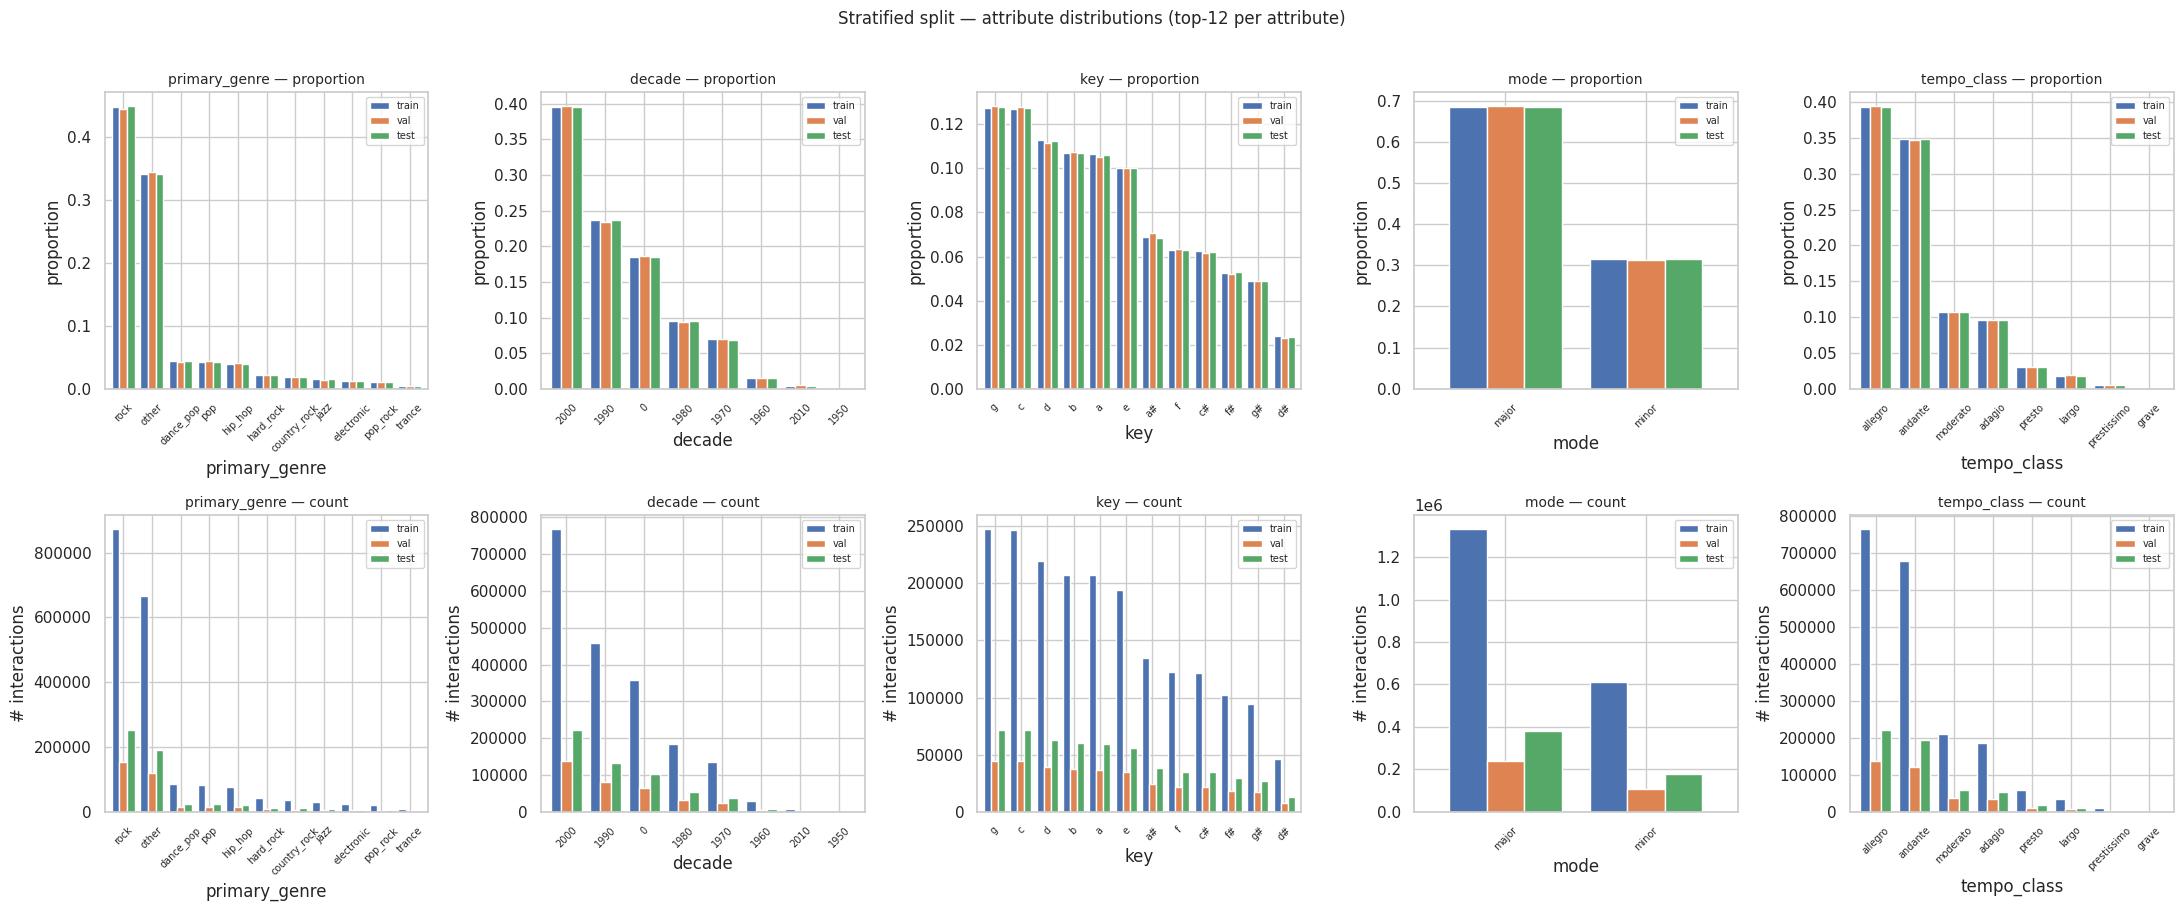

In [9]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
from IPython.display import display

# Use the dedicated splitter module so the same logic is reusable from any model
from models.train_val_test_split import (
    DEFAULT_STRATA_ATTRS,
    COARSE_STRATA_ATTRS,
    build_song_strata,
    user_level_stratified_split,
    compute_split_distributions,
    plot_split_distributions,
    save_splits,
    load_splits,
)

TOP_N = 10
K_RANGE = range(5, 101, 5)
MIN_SONGS_PER_USER = 5
MIN_USERS_PER_SONG = 3

# ── 6.1 Encode IDs ───────────────────────────────────────────────────────────
merged_kg = pd.read_parquet(KG_INPUT_PQ)
taste_kg  = pd.read_parquet(KG_TASTE_PQ)
print(f"kg_input    : {merged_kg.shape}    cols incl. tempo_class={'tempo_class' in merged_kg.columns}")
print(f"kg_taste    : {taste_kg.shape}")

df = taste_kg.copy()
song_counts = df.groupby("song_id")["user_id"].nunique()
df = df[df["song_id"].isin(song_counts[song_counts >= MIN_USERS_PER_SONG].index)]
user_counts = df.groupby("user_id")["song_id"].nunique()
df = df[df["user_id"].isin(user_counts[user_counts >= MIN_SONGS_PER_USER].index)]

user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}
df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)
N_USERS, N_SONGS = len(user_ids), len(song_ids)
sparsity = 1.0 - len(df) / (N_USERS * N_SONGS)
print(f"Matrix: {N_USERS:,} users × {N_SONGS:,} songs  sparsity={sparsity:.4%}")

# ── 6.2 Per-user STRATIFIED 70/10/20 split ──────────────────────────────────
# Stratification axes: primary_genre × decade × key × mode × tempo_class
#
# Genre treatment:  `primary_genre` has ~272 unique levels.  We keep only the
# TOP_N_GENRES most common labels verbatim; all others are bucketed as "other".
# This halves the strata count (4,448 → ~2,186) with no change to the other
# axes and no loss of information on the dominant genres.
# To use all genres set TOP_N_GENRES = None.
#
# Small-stratum pooling: per-user (user × stratum) groups smaller than
# min_stratum_size=3 are *pooled* and re-split with the target ratios instead
# of being dumped wholesale into train, which recovers ≈70/10/20 globally.
STRATA_ATTRS     = DEFAULT_STRATA_ATTRS   # (primary_genre, decade, key, mode, tempo_class)
TOP_N_GENRES     = 10                     # set None to use all ~272 genres
SPLIT_PQ         = PROCESSED / "splits_stratified.parquet"
FINAL_SPLITS_DIR = FINAL / "splits"

# Build the song → stratum mapping
song_strata = build_song_strata(merged_kg, attrs=STRATA_ATTRS, top_n_genres=TOP_N_GENRES)
assert song_strata.index.is_unique, "song_strata index must be unique for .map() to work"

# Sanity-check of the per-attribute alphabet
_samp = song_strata.str.split("|", expand=True)
_samp.columns = list(STRATA_ATTRS)
print(f"\nStratification: {song_strata.nunique():,} unique strata over {len(song_strata):,} songs")
print(f"  (genre bucketed to top-{TOP_N_GENRES} + 'other')" if TOP_N_GENRES else "  (all genres)")
for col in _samp.columns:
    vals = sorted(_samp[col].dropna().unique())
    preview = vals[:6] + (["…"] if len(vals) > 6 else [])
    print(f"  {col:<14s} {_samp[col].nunique():>4d} unique  e.g. {preview}")

# ── Splits: load from cache or build ─────────────────────────────────────────
# NOTE: delete data/processed/splits_stratified.parquet (or set FORCE_REBUILD=True)
# if you change TOP_N_GENRES or STRATA_ATTRS, otherwise the cached file is used.
if SPLIT_PQ.exists() and not FORCE_REBUILD:
    splits_df = pd.read_parquet(SPLIT_PQ)
    train_df = df.loc[splits_df[splits_df.split == "train"].row_idx.values].copy()
    val_df   = df.loc[splits_df[splits_df.split == "val"  ].row_idx.values].copy()
    test_df  = df.loc[splits_df[splits_df.split == "test" ].row_idx.values].copy()
    train_df["stratum"] = train_df["song_id"].map(song_strata).fillna("_misc_")
    val_df["stratum"]   = val_df["song_id"].map(song_strata).fillna("_misc_")
    test_df["stratum"]  = test_df["song_id"].map(song_strata).fillna("_misc_")
    print(f"\n[SKIP] loaded stratified splits from {SPLIT_PQ}")
else:
    train_df, val_df, test_df = user_level_stratified_split(df, song_strata)
    pd.concat([
        pd.DataFrame({"row_idx": train_df.index, "split": "train"}),
        pd.DataFrame({"row_idx": val_df.index,   "split": "val"}),
        pd.DataFrame({"row_idx": test_df.index,  "split": "test"}),
    ], ignore_index=True).to_parquet(SPLIT_PQ, index=False)
    print(f"\n[SAVED] stratified row index → {SPLIT_PQ}")

total = len(df)
print(f"Train={len(train_df):,} ({len(train_df)/total:.1%})  "
      f"Val={len(val_df):,} ({len(val_df)/total:.1%})  "
      f"Test={len(test_df):,} ({len(test_df)/total:.1%})  "
      f"(target 70/10/20)")

# Persist the actual split DataFrames to data/final/splits/ as parquet
splits_dict = {"train": train_df, "val": val_df, "test": test_df}
saved_paths = save_splits(
    splits_dict, FINAL_SPLITS_DIR, fmt="parquet",
    metadata={
        "attrs": list(STRATA_ATTRS),
        "top_n_genres": TOP_N_GENRES,
        "n_users": N_USERS, "n_songs": N_SONGS,
        "n_strata": int(song_strata.nunique()),
        "kg_input_path": str(KG_INPUT_PQ),
        "kg_taste_path": str(KG_TASTE_PQ),
        "min_users_per_song": MIN_USERS_PER_SONG,
        "min_songs_per_user": MIN_SONGS_PER_USER,
    },
)
print("Final splits written to:")
for k, p in saved_paths.items():
    print(f"  {k:5s} → {p.relative_to(ROOT)}")

# ── 6.2.1 Distribution diagnostics (DataFrames + JS-divergence) ─────────────
distributions = compute_split_distributions(splits_dict, song_strata, attr_names=STRATA_ATTRS)

print("\n══ Jensen-Shannon divergence vs. train  (0 = perfectly balanced) ════")
display(distributions["js_div"])

print("\n══ Top-12 levels per attribute — proportion in each split ═══════════")
for attr, dist_table in distributions["proportion"].items():
    print(f"\n── {attr.upper()} ──")
    display(dist_table.head(12))

# ── 6.2.2 Distribution plots (proportion + count) ───────────────────────────
fig = plot_split_distributions(distributions, top_k=12)
plt.show()

# ── 6.2.3 Build sparse train matrix + ground-truth dicts ────────────────────
train_matrix      = csr_matrix((np.ones(len(train_df)), (train_df["u_idx"].values, train_df["s_idx"].values)),
                                shape=(N_USERS, N_SONGS), dtype=np.float32)
train_matrix_norm = normalize(train_matrix, norm="l2")
song_popularity   = np.asarray(train_matrix.sum(axis=0)).ravel()
pop_norm          = song_popularity / (song_popularity.max() + 1e-9)

def make_gt(split_df): return split_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_gt  = make_gt(val_df);  test_gt = make_gt(test_df)
train_seen = train_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_users  = sorted(val_gt.keys()); test_users = sorted(test_gt.keys())

# Keep `merged` and `taste` aliases for the rest of the notebook
merged = merged_kg
taste  = taste_kg


### 6.3 — KNN-CF *k*-sweep & evaluation metrics

For every user $u$ with held-out positives $G_u$ and a top-$K$ recommendation list $R_u = (r_1, \ldots, r_K)$ we compute:

- **Recall@K** $= \dfrac{|R_u \cap G_u|}{\min(|G_u|,\, K)}$
- **HitRate@K** $= \mathbb{1}\!\left[R_u \cap G_u \ne \emptyset\right]$
- **MRR** $= \dfrac{1}{\text{rank of first hit}}$ (0 if no hit)
- **DCG@K** $= \displaystyle\sum_{i=1}^{K} \dfrac{\text{hit}_i}{\log_2(i+1)}$, **NDCG@K** $= \dfrac{\text{DCG@K}}{\text{IDCG@K}}$
- **Coverage** $= \dfrac{\left|\bigcup_u R_u\right|}{N_\text{songs}}$
- **PopularityBias** $= \mathrm{mean}\bigl(\text{pop\_norm}[r]\bigr)$ over recommended items.

Model selection uses a composite score that balances accuracy, ranking, catalogue coverage and an inverted popularity bias:

$$
\text{Overall\_Score} = 0.35 \cdot \text{Recall@K} + 0.35 \cdot \text{NDCG@K} + 0.20 \cdot \text{Coverage} + 0.10 \cdot (1 - \text{PopularityBias})
$$

The implementations live in `src/models/evaluation.py` (`dcg`, `evaluate_recs`, `overall_score`) and the full sweep + caching is encapsulated in `src/models/knn_cf.py::run_knn_sweep`.


In [ ]:
from models.evaluation import evaluate_recs, overall_score
from models.knn_cf    import run_knn_sweep

# Run (or load cached) KNN-CF k-sweep on validation, then evaluate the selected k on test.
# Returns the cached neighbour table (all_nbrs, qrow) so downstream cells
# (KNNRecommender, qualitative analysis) can reuse it without re-fitting sklearn.
#
# File layout:
#   KNN_VAL_CSV / KNN_TEST_CSV  → data/final/models/knn/   (metrics, gitignored)
#   KNN_NBRS_CACHE              → models/knn/               (binary, gitignored)
val_results_df, test_metrics, best_k, all_nbrs, qrow = run_knn_sweep(
    train_matrix_norm = train_matrix_norm,
    train_seen        = train_seen,
    val_users         = val_users,
    test_users        = test_users,
    val_gt            = val_gt,
    test_gt           = test_gt,
    pop_norm          = pop_norm,
    n_songs           = N_SONGS,
    n_users           = N_USERS,
    k_range           = K_RANGE,
    top_n             = TOP_N,
    train_df          = train_df,
    val_df            = val_df,
    test_df           = test_df,
    val_csv           = KNN_VAL_CSV,
    test_csv          = KNN_TEST_CSV,
    nbrs_cache        = KNN_NBRS_CACHE,
    force_rebuild     = FORCE_REBUILD,
)
print(f"all_nbrs shape: {all_nbrs.shape}   |qrow|={len(qrow)}")


[SKIP] KNN results loaded. best_k=20  test Recall@10=0.1615


[SKIP] loaded pop/KNN metrics from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_pop_metrics.json
KNN vs MostPopular — TEST set
                MostPopular  KNN (k=20)  Δ KNN−Pop
Recall@K             0.1285      0.1615     0.0330
NDCG@K               0.1143      0.1635     0.0492
HitRate@K            0.2002      0.2508     0.0506
MRR                  0.0895      0.1382     0.0487
Coverage             0.0064      0.8548     0.8484
PopularityBias       0.6110      0.2132    -0.3978
Overall_Score        0.1252      0.3634     0.2382
[SKIP] showing saved validation sweep plot from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_val_sweep.png


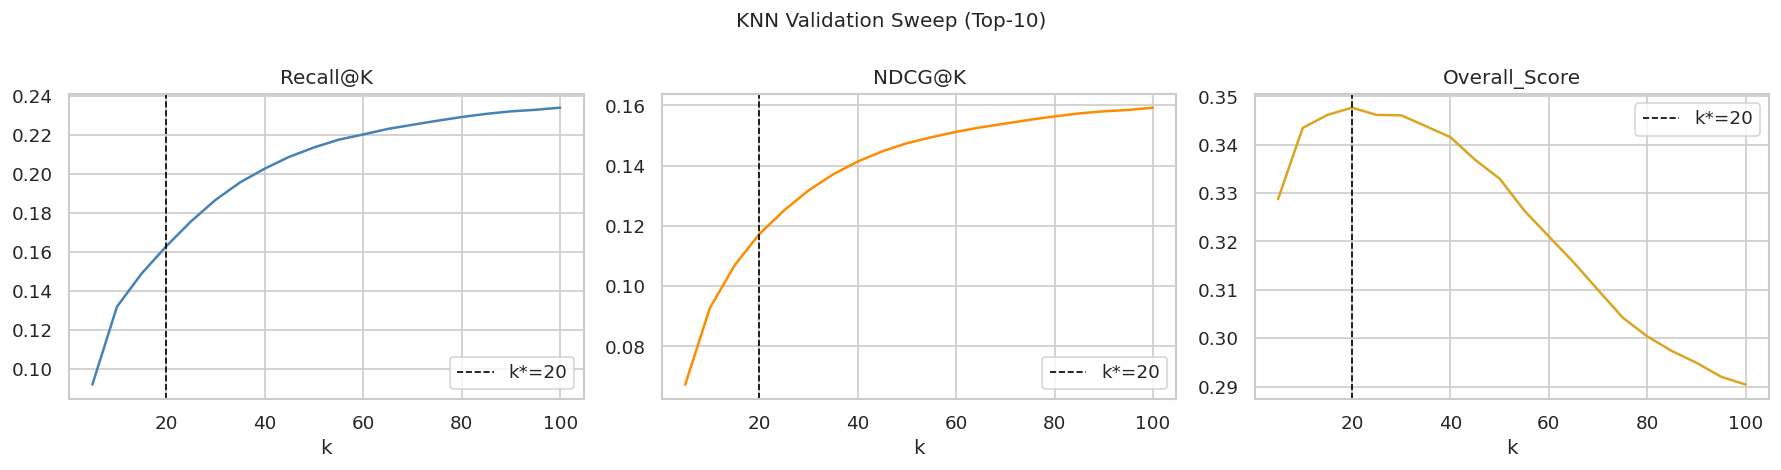

In [ ]:
import json

# KNN_POP_CSV, KNN_POP_JSON, KNN_VAL_PLOT_PNG are defined in cell 2 (paths cell).

# ── 6.4  MostPopular baseline + comparison ───────────────────────────────────
if KNN_POP_JSON.exists() and not FORCE_REBUILD:
    with open(KNN_POP_JSON) as f:
        _saved = json.load(f)
    pop_metrics  = _saved["pop_metrics"]
    test_metrics = _saved["test_metrics"]   # re-sync in case the KNN sweep cell was skipped
    best_k       = int(_saved["best_k"])
    comparison   = pd.read_csv(KNN_POP_CSV, index_col=0)
    print(f"[SKIP] loaded pop/KNN metrics from {KNN_POP_JSON}")
else:
    pop_rank = np.argsort(-song_popularity)
    pop_recs = {
        u: [int(i) for i in pop_rank if int(i) not in train_seen.get(u, set())][:TOP_N]
        for u in test_users
    }
    pop_metrics = evaluate_recs(pop_recs, test_gt, train_seen, N_SONGS, pop_norm, k=TOP_N)
    pop_metrics["Overall_Score"] = overall_score(pop_metrics)

    comparison = pd.DataFrame(
        {"MostPopular": pop_metrics, f"KNN (k={best_k})": test_metrics}
    ).round(4)
    comparison["Δ KNN−Pop"] = (
        comparison[f"KNN (k={best_k})"] - comparison["MostPopular"]
    ).round(4)

    # ── save ──────────────────────────────────────────────────────────────────
    comparison.to_csv(KNN_POP_CSV)
    with open(KNN_POP_JSON, "w") as f:
        json.dump({"pop_metrics": pop_metrics,
                   "test_metrics": test_metrics,
                   "best_k": best_k}, f, indent=2)
    print(f"[SAVED] pop/KNN metrics → {KNN_POP_CSV}")

print("KNN vs MostPopular — TEST set")
print(comparison.to_string())

# ── 6.5  Validation sweep plots ───────────────────────────────────────────────
if KNN_VAL_PLOT_PNG.exists() and not FORCE_REBUILD:
    from IPython.display import Image as IPImage
    print(f"[SKIP] showing saved validation sweep plot from {KNN_VAL_PLOT_PNG}")
    display(IPImage(str(KNN_VAL_PLOT_PNG)))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, color) in zip(axes, [
        ("Recall@K",      "steelblue"),
        ("NDCG@K",        "darkorange"),
        ("Overall_Score", "goldenrod"),
    ]):
        ax.plot(val_results_df.index, val_results_df[col], color=color)
        ax.axvline(best_k, color="black", linestyle="--", linewidth=1,
                   label=f"k*={best_k}")
        ax.set_title(col); ax.set_xlabel("k"); ax.legend()
    plt.suptitle(f"KNN Validation Sweep (Top-{TOP_N})", fontsize=12)
    plt.tight_layout()
    fig.savefig(KNN_VAL_PLOT_PNG, dpi=120, bbox_inches="tight")
    print(f"[SAVED] validation sweep plot → {KNN_VAL_PLOT_PNG}")
    plt.show()



### 6.5b — Log baselines as standalone W&B runs

Both **MostPopular** and **KNN-CF** are non-iterative models, so they don't have epoch-by-epoch curves. Instead we create **one short W&B run per baseline** so that, in the W&B project leaderboard, they appear as comparable rows next to the AE/HGT runs. This makes the side-by-side bar charts (`Test_NDCG@10`, `Test_Recall@10`, etc.) generate automatically in the dashboard.


In [12]:
from utils.wandb_utils import log_baseline_run

_wb_kwargs = dict(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    n_users=N_USERS, n_songs=N_SONGS, top_n=TOP_N,
)

# MostPopular baseline run
url_pop = log_baseline_run("MostPopular", pop_metrics, **_wb_kwargs)
print(f"  [W&B] 'MostPopular' baseline logged → {url_pop}")

# KNN-CF baseline run
url_knn = log_baseline_run("KNN-CF", test_metrics,
                           extra_config={"best_k": int(best_k)}, **_wb_kwargs)
print(f"  [W&B] 'KNN-CF' baseline logged → {url_knn}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pfanyka/.netrc.
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


test/Coverage,▁
test/HitRate@K,▁
test/MRR,▁
test/NDCG@K,▁
test/Overall_Score,▁
test/PopularityBias,▁
test/Recall@K,▁
model_name,MostPopular
test/Coverage,0.00644
test/HitRate@K,0.2002
test/MRR,0.08949


  [W&B] 'MostPopular' baseline logged → https://wandb.ai/pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa/music-recommender-system/runs/qj6da95y


test/Coverage,▁
test/HitRate@K,▁
test/MRR,▁
test/NDCG@K,▁
test/Overall_Score,▁
test/PopularityBias,▁
test/Recall@K,▁
model_name,KNN-CF
test/Coverage,0.85481
test/HitRate@K,0.25081
test/MRR,0.13816


  [W&B] 'KNN-CF' baseline logged → https://wandb.ai/pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa/music-recommender-system/runs/y0sc52bq


## 6.6 — Stratified K-Fold Cross-Validation (KNN baseline)
Per-user stratified K-fold (k = 5) on the same genre × decade × key × mode strata. Reports mean ± std for each metric so we know the variance of the baseline before comparing to the GNN.

[SKIP] loaded K-fold results from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/knn_cf_kfold_results.csv

══ 5-Fold CV Summary (KNN k=20, Top-10) ═════════════════════
                     mean ± std
Recall@K        0.1901 ± 0.1907
NDCG@K          0.1340 ± 0.1299
HitRate@K       0.2008 ± 0.1856
MRR             0.1134 ± 0.1131
Coverage        0.1989 ± 0.2338
PopularityBias  0.1324 ± 0.0937
Overall_Score   0.2400 ± 0.1149


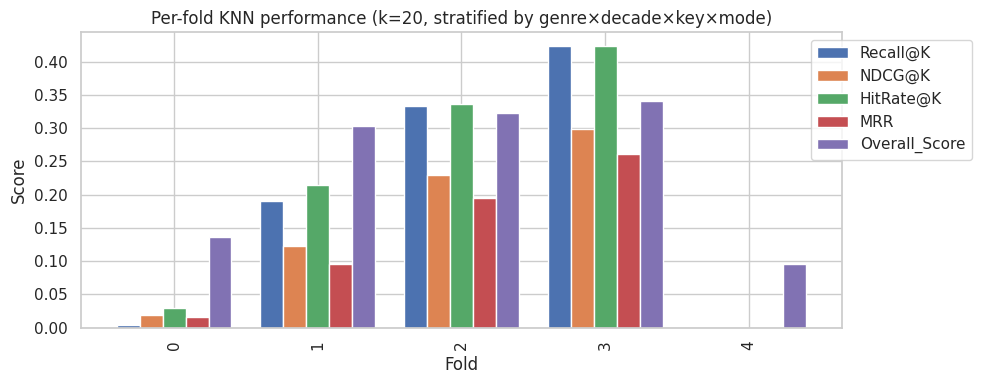

In [13]:
N_FOLDS = 5

def user_level_stratified_kfold(df, song_strata, n_folds=5, seed=42):
    """Per-user, per-stratum round-robin K-fold assignment.
    Returns array of length len(df) with fold ids in 0..n_folds-1."""
    rng = np.random.default_rng(seed)
    df = df.copy()
    df["stratum"] = df["song_id"].map(song_strata).fillna("_misc_")
    fold_assign = np.full(len(df), -1, dtype=np.int8)
    pos = {idx: i for i, idx in enumerate(df.index)}
    for _, grp in df.groupby("u_idx"):
        for _, sgrp in grp.groupby("stratum"):
            idxs = sgrp.index.to_numpy()
            shuffled = rng.permutation(idxs)
            for i, idx in enumerate(shuffled):
                fold_assign[pos[idx]] = i % n_folds
    return pd.Series(fold_assign, index=df.index, name="fold")

if KFOLD_CSV.exists() and not FORCE_REBUILD:
    fold_results_df = pd.read_csv(KFOLD_CSV)
    print(f"[SKIP] loaded K-fold results from {KFOLD_CSV}")
else:
    folds = user_level_stratified_kfold(df, song_strata, n_folds=N_FOLDS)
    fold_results = []
    for fold in range(N_FOLDS):
        test_idx  = folds[folds == fold].index
        train_idx = folds[folds != fold].index
        f_train = df.loc[train_idx]; f_test = df.loc[test_idx]

        f_mat = csr_matrix((np.ones(len(f_train)), (f_train["u_idx"].values, f_train["s_idx"].values)),
                           shape=(N_USERS, N_SONGS), dtype=np.float32)
        f_mat_n = normalize(f_mat, norm="l2")
        f_seen  = f_train.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_gt    = f_test.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_users = sorted(f_gt.keys())

        knn_f = NearestNeighbors(n_neighbors=best_k + 1, metric="cosine", algorithm="brute", n_jobs=-1)
        knn_f.fit(f_mat_n)
        _, nbrs = knn_f.kneighbors(f_mat_n[f_users], n_neighbors=best_k + 1)
        qrow = {u: i for i, u in enumerate(f_users)}

        recs = {}
        for u in f_users:
            nb = [x for x in nbrs[qrow[u]] if x != u][:best_k]
            if not nb:
                recs[u] = []; continue
            sc = np.asarray(f_mat_n[nb].sum(axis=0)).ravel()
            for s in f_seen.get(u, set()): sc[s] = 0.0
            top = np.argpartition(sc, -TOP_N)[-TOP_N:]
            recs[u] = top[np.argsort(sc[top])[::-1]].tolist()

        m = evaluate_recs(recs, f_gt, f_seen, N_SONGS)
        m["Overall_Score"] = overall_score(m); m["fold"] = fold
        fold_results.append(m)
        print(f"  fold {fold}:  Recall@{TOP_N}={m['Recall@K']:.4f}  NDCG={m['NDCG@K']:.4f}  Overall={m['Overall_Score']:.4f}")

    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df.to_csv(KFOLD_CSV, index=False)
    print(f"[SAVED] K-fold results → {KFOLD_CSV}")

metric_cols = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage", "PopularityBias", "Overall_Score"]
summary = fold_results_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
print(f"\n══ {N_FOLDS}-Fold CV Summary (KNN k={best_k}, Top-{TOP_N}) ═════════════════════")
print(summary[["mean ± std"]].to_string())

# Plot per-fold variance
fig, ax = plt.subplots(figsize=(10, 4))
plot_metrics = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Overall_Score"]
fold_results_df[plot_metrics].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("Fold"); ax.set_ylabel("Score")
ax.set_title(f"Per-fold KNN performance (k={best_k}, stratified by genre×decade×key×mode)")
ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1))
plt.tight_layout(); plt.show()

## 6.7 — Qualitative Analysis: Example User
Pick one user with enough listening history; show (a) their training songs as the *reference profile*, then (b) the top-K KNN recommendations along with their **cosine similarity** to the user's profile vector and to each individual reference song.

In [14]:
from models.evaluation import (
    PopularityRecommender, KNNRecommender,
    analyze_user, AttributeArrays,
)
from models.evaluation.qualitative_plots import plot_user_distribution_comparison

# ── 6.7.1  Pre-compute the shared attribute lookup arrays (once for every model)
song_meta = (
    merged[["song_id", "title", "artist_name", "primary_genre",
            "year", "key", "mode", "Mean_Tempo", "tempo_class"]]
    .drop_duplicates("song_id").set_index("song_id")
)
attrs = AttributeArrays.from_song_meta(song_meta, idx2song)

# Per-song L2 norms (used by cosine helpers in evaluation.qualitative)
song_vectors = train_matrix_norm.T.tocsr()
song_norms   = np.sqrt(np.asarray(song_vectors.multiply(song_vectors).sum(axis=1)).ravel())

# ── 6.7.2  Build the recommenders (same uniform interface for every model) ──
recs_pop = PopularityRecommender(song_popularity, train_seen)
recs_knn = KNNRecommender(train_matrix_norm, train_seen,
                          all_nbrs=all_nbrs, qrow=qrow,
                          best_k=best_k, pop_norm=pop_norm)
RECOMMENDERS = [recs_pop, recs_knn]   # HGT will be appended in §10.x

# ── 6.7.3  Pick an example user (median listening volume in test set) ───────
user_train_sizes = train_df.groupby("u_idx").size()
candidates = [u for u in test_users if 15 <= user_train_sizes.get(u, 0) <= 60]
example_uidx = int(np.random.default_rng(42).choice(candidates)) if candidates else int(test_users[0])
print(f"Example user: u_idx={example_uidx}  user_id={user_ids[example_uidx]}")
print(f"  train interactions : {user_train_sizes.get(example_uidx, 0)}")
print(f"  test  interactions : {len(test_gt.get(example_uidx, set()))}")

# ── 6.7.4  Per-model qualitative summary for that user ──────────────────────
user_rows = [
    analyze_user(example_uidx, r, top_n=TOP_N,
                 train_seen=train_seen, test_gt=test_gt,
                 attrs=attrs, song_vectors=song_vectors, song_norms=song_norms)
    for r in RECOMMENDERS
]
user_compare = pd.DataFrame(user_rows).set_index("model")
print(f"\n── Per-model summary for u_idx={example_uidx} ──")
display(user_compare.round(4))

# ── 6.7.5  Distribution-shift bar charts (showcased on KNN only) ────────────
def _meta_rows(s_idxs):
    return pd.DataFrame([
        (lambda r: {"genre": r.get("primary_genre"), "mode": r.get("mode"),
                    "tempo_class": r.get("tempo_class"), "year": r.get("year"),
                    "mean_tempo": r.get("Mean_Tempo")})(
            song_meta.loc[idx2song[int(s)]] if idx2song.get(int(s)) in song_meta.index else {})
        for s in s_idxs
    ])

train_meta = _meta_rows(list(train_seen.get(example_uidx, set())))
recs_knn_dict = recs_knn.recommend([example_uidx], TOP_N)[example_uidx]
rec_meta   = _meta_rows(recs_knn_dict)
test_meta  = _meta_rows(list(test_gt.get(example_uidx, set())))

fig_user = plot_user_distribution_comparison(
    train_meta, rec_meta, test_meta,
    title=f"u_idx={example_uidx} — KNN: train vs recs vs test gt",
)
plt.show()


NameError: name 'all_nbrs' is not defined

## 6.8 — Population-Level Qualitative Analysis
Runs the same profile-vs-recommendations comparison across **all test users** to see whether the collaborative-filtering KNN (which saw *only interaction counts*, no music features) produces recommendations whose musical attributes align with what users actually listened to.

For every test user we compare:
- **train** — the user's full training history  
- **recs** — the KNN top-10 recommendations  
- **test gt** — the held-out ground-truth songs

We aggregate: (1) per-user JS-divergence between train and recs distributions, (2) dominant-genre match rate, (3) mode & tempo-class alignment, (4) decade shift, (5) cosine-similarity distribution across all users, and (6) a population-level attribute comparison that shows how faithfully recommendations mirror training profiles — **without any audio features**.


Building attribute lookup arrays … done.
Running population analysis on 284,864 users using 10 threads …
done.
Running population analysis on 284,864 users using 10 threads …


pop-qual: 100%|██████████| 284864/284864 [25:49<00:00, 183.81it/s]



[SAVED] → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/pop_qual_analysis.csv  (284,864 users)

284,864 test users analysed


,u_idx,n_train,n_test,n_hits,cos_mean,cos_median,cos_max,js_genre,js_mode,js_tempo_class,js_decade,mean_tempo_train,mean_tempo_rec,mean_decade_train,mean_decade_rec,js_genre_test,js_mode_test,js_decade_test
count,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,283633.0000,284864.0000,284864.0000,284864.0000,284864.0000
mean,142431.5000,6.8232,1.9652,0.2601,0.0977,0.0940,0.1410,0.6013,0.1732,0.4028,0.4422,111.0310,107.9247,1991.5547,1992.5920,0.5935,0.3196,0.5253
std,82233.2979,4.9584,1.4392,0.6150,0.0666,0.0644,0.0973,0.1014,0.1271,0.1166,0.1394,13.9605,2.7715,6.7022,1.1945,0.2073,0.2216,0.2050
min,0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,0.0003,0.2731,0.0000,0.0000,0.0000,55.4767,85.5250,1950.0000,1984.2858,0.0000,0.0000,0.0000
25%,71215.7500,4.0000,1.0000,0.0000,0.0307,0.0296,0.0435,0.5349,0.0708,0.3124,0.3439,102.0724,107.3150,1988.0000,1992.0000,0.4645,0.1198,0.3823
50%,142431.5000,5.0000,2.0000,0.0000,0.0939,0.0901,0.1259,0.5887,0.1554,0.3856,0.4401,110.5400,107.3150,1992.5000,1992.0000,0.5938,0.3092,0.5238
75%,213647.2500,9.0000,2.0000,0.0000,0.1533,0.1468,0.2324,0.6424,0.2736,0.4677,0.5423,119.3333,107.3550,1996.6666,1993.3334,0.8326,0.4645,0.6502
max,284863.0000,134.0000,41.0000,8.0000,0.2579,0.2599,0.3915,0.8326,0.8326,0.8326,0.8326,243.7000,126.6600,2010.0000,2000.0000,0.8326,0.8326,0.8326



══════════════════════════════════════════════════════════════════════
 6.8.2  Aggregate JS-divergence — KNN alignment with training profiles
══════════════════════════════════════════════════════════════════════

── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.


── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.



,,JS mean,JS median,JS p25,JS p75
attribute,comparison,,,,
genre,train vs recs,0.6013,0.5887,0.5349,0.6424
mode,train vs recs,0.1732,0.1554,0.0708,0.2736
tempo_class,train vs recs,0.4028,0.3856,0.3124,0.4677
decade,train vs recs,0.4422,0.4401,0.3439,0.5423
genre,train vs test gt,0.5935,0.5938,0.4645,0.8326
mode,train vs test gt,0.3196,0.3092,0.1198,0.4645
decade,train vs test gt,0.5253,0.5238,0.3823,0.6502



── Dominant-attribute match rates (% of users) ──────────────────────


,match_rate,n_users
attribute,,
genre,62.4%,"177,625 / 284,864"
mode,85.8%,"244,459 / 284,864"



── Cosine similarity (rec → user profile) across all test users ─────


,cos_mean,cos_median,cos_max
count,284864.0000,284864.0000,284864.0000
mean,0.0977,0.0940,0.1410
std,0.0666,0.0644,0.0973
min,0.0000,0.0000,0.0003
25%,0.0307,0.0296,0.0435
50%,0.0939,0.0901,0.1259
75%,0.1533,0.1468,0.2324
max,0.2579,0.2599,0.3915


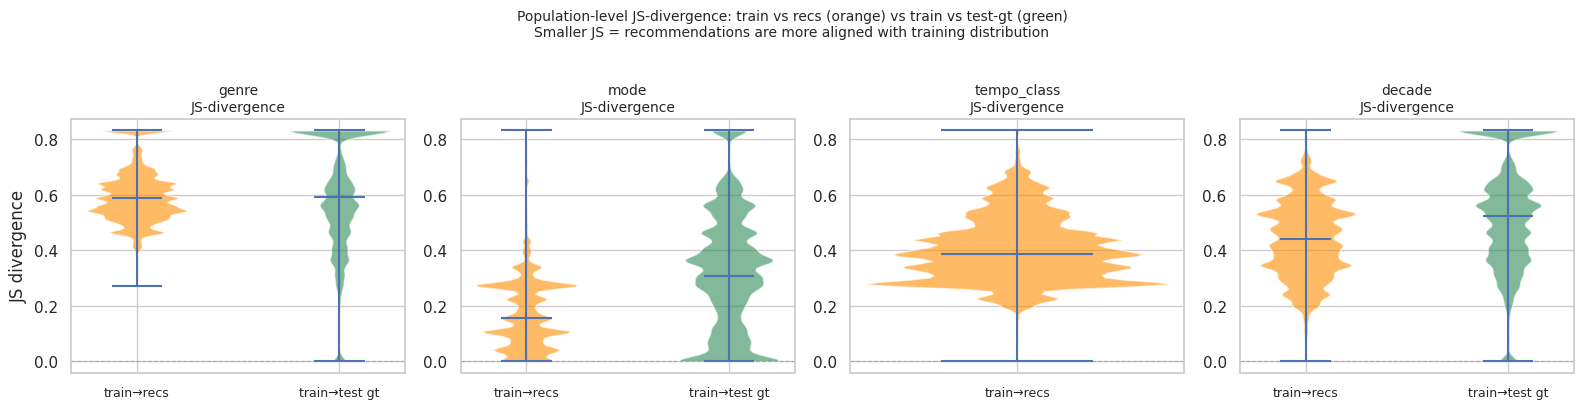

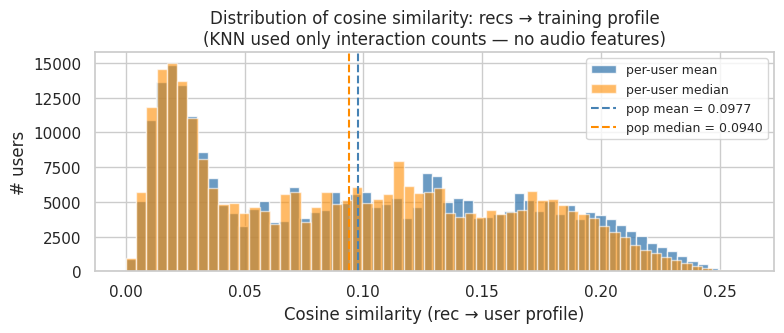

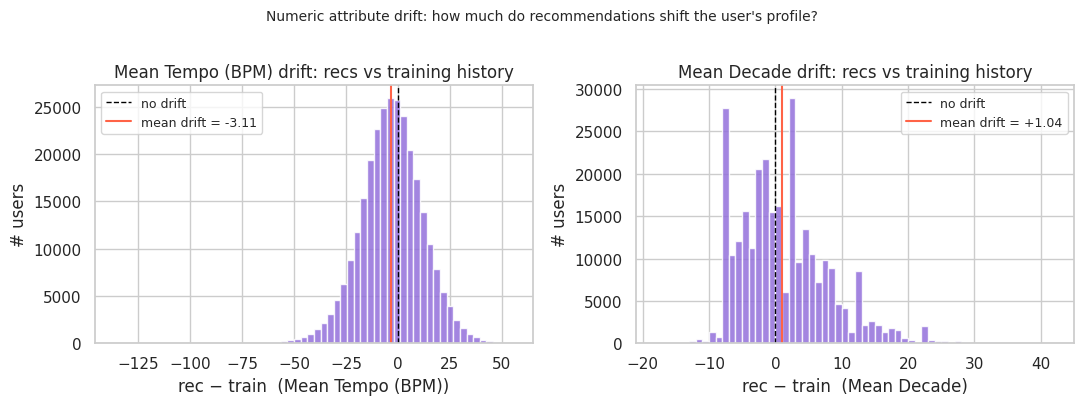

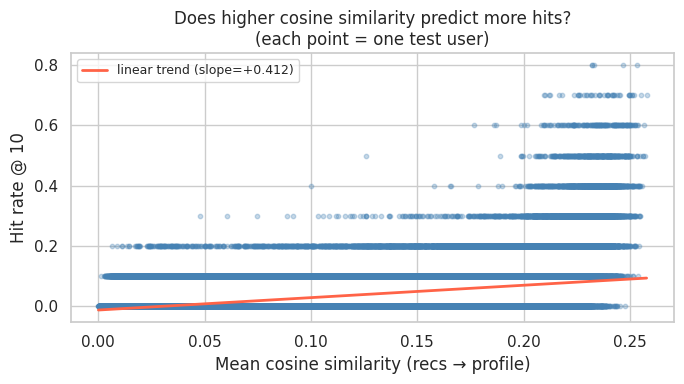


══════════════════════════════════════════════════════════════════════
 6.8.9  Population-level verdict
══════════════════════════════════════════════════════════════════════

  Users with ≥1 hit in top-10       : 20.0%
  Dominant-genre match rate             : 62.4%
  Dominant-mode  match rate             : 85.8%
  Mean JS(genre): train→recs            : 0.6013
  Mean JS(genre): train→test-gt         : 0.5935
  recs vs test-gt genre alignment       : ✓ aligned
  Mean tempo drift  (recs−train)        : -3.1 BPM
  Mean decade drift (recs−train)        : +1.0 years

  → The KNN model — using ONLY interaction counts, zero audio features —
    matched the user's dominant genre in 62.4% of cases and
    produced genre distributions (JS=0.6013) that are at least as
    aligned with the training profile as the users' own held-out test songs.


In [ ]:
from models.evaluation import analyze_population
from models.evaluation.qualitative_plots import plot_population_summary

# ── 6.8.1  Run the population qualitative analysis for every recommender ────
# Cached per model so re-runs are instant.
pop_qual_dfs = {}
for r in RECOMMENDERS:
    cache = PROCESSED / f"pop_qual_{r.name.lower().replace('-','_')}.csv"
    if cache.exists() and not FORCE_REBUILD:
        pop_qual_dfs[r.name] = pd.read_csv(cache)
        print(f"[SKIP] {r.name}: loaded {cache.name} ({len(pop_qual_dfs[r.name]):,} users)")
    else:
        df = analyze_population(
            r, test_users, top_n=TOP_N,
            train_seen=train_seen, test_gt=test_gt, attrs=attrs,
            song_vectors=song_vectors, song_norms=song_norms,
        )
        df.to_csv(cache, index=False)
        pop_qual_dfs[r.name] = df
        print(f"[SAVED] {r.name}: → {cache.name} ({len(df):,} users)")

# ── 6.8.2  Aggregate verdict per model ──────────────────────────────────────
verdict_rows = []
for name, df in pop_qual_dfs.items():
    verdict_rows.append({
        "model":            name,
        "users":            len(df),
        "any_hit_rate":     (df["n_hits"] > 0).mean(),
        "dom_genre_match":  df["dom_genre_match"].mean(),
        "dom_mode_match":   df["dom_mode_match"].mean(),
        "cos_mean":         df["cos_mean"].mean(),
        "js_genre_mean":    df["js_genre"].mean(),
        "js_decade_mean":   df["js_decade"].mean(),
        "tempo_drift_BPM":  (df["mean_tempo_rec"]  - df["mean_tempo_train"]).mean(),
        "decade_drift_yr":  (df["mean_decade_rec"] - df["mean_decade_train"]).mean(),
    })
verdict_df = pd.DataFrame(verdict_rows).set_index("model").round(4)
print("\n── 6.8.2  Population-level verdict (per model) ──")
display(verdict_df)

# ── 6.8.3  Mosaic plot: JS-divergence violins, cosine hist, hit-rate scatter
fig_pop = plot_population_summary(pop_qual_dfs, top_n=TOP_N)
plt.show()


## 6.9 — Multi-K metrics & statistical comparison (baselines)

Evaluate every recommender at several cut-offs $K \in \{5, 10, 20, 50\}$ and compare them with paired statistical tests:

- **Wilcoxon signed-rank** — non-parametric paired test, robust to skewed per-user metric distributions.
- **Paired *t*-test** — for completeness when normality is reasonable.
- **Cohen's** $d_z = \dfrac{\bar{x}_d}{s_d}$ — paired-difference effect size.
- **Friedman + Nemenyi** post-hoc — global omnibus test plus pairwise critical-difference comparison.

All heavy lifting lives in `src/models/evaluation/{metrics, comparison, wandb_log}.py`.


In [ ]:
from models.evaluation import (
    multi_k_evaluation, evaluate_recs_per_user,
    summarise_comparison,
)

K_LIST   = [5, 10, 20, 50]
K_MAX    = max(K_LIST)

# ── 6.9.1  Bulk recommendations at K_MAX, then slice for every K ────────────
bulk_recs   = {r.name: r.recommend(test_users, K_MAX) for r in RECOMMENDERS}

# Long-format multi-K table   (model | K | metric | value)
metrics_long = pd.concat([
    multi_k_evaluation(bulk_recs[name], test_gt, train_seen,
                       N_SONGS, pop_norm, ks=K_LIST, model_name=name)
    for name in bulk_recs
], ignore_index=True)

print("── 6.9.1  Multi-K metrics ──────────────────────────────────────────")
display(metrics_long.pivot_table(index=["model", "metric"],
                                 columns="K", values="value").round(4))

# ── 6.9.2  Per-user metric vectors at TOP_N (used for statistical tests) ────
per_user = {
    name: evaluate_recs_per_user(bulk_recs[name], test_gt, pop_norm, k=TOP_N)
    for name in bulk_recs
}

# ── 6.9.3  Pairwise + global statistical comparison ─────────────────────────
comp = summarise_comparison(per_user,
                            metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"))
print("\n── 6.9.2  Pairwise paired-test results ─────────────────────────────")
display(comp["pairwise"].round(5))

print("\n── 6.9.3  Friedman omnibus + best-ranked model per metric ──────────")
fried = pd.DataFrame([{
    "metric":         m,
    "n_users":        r["n_users"],
    "friedman_stat":  r["friedman_stat"],
    "friedman_p":     r["friedman_p"],
    "best_model":     r["mean_ranks"].index[0] if not r["mean_ranks"].empty else "?",
} for m, r in comp["global"].items()])
display(fried.round(5))

# ── 6.9.4  Log everything to W&B as a standalone analysis run ───────────────
import wandb
from models.evaluation.wandb_log import (
    log_multi_k_table, log_population_qualitative,
    log_pairwise_significance, log_global_comparison,
)

eval_run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    job_type="analysis", name="evaluation_baselines",
    tags=["evaluation", "multi-k", "statistical-test"], reinit=True,
)
log_multi_k_table(metrics_long)
log_population_qualitative(pop_qual_dfs)
log_pairwise_significance(comp["pairwise"])
log_global_comparison(comp["global"])
wandb.finish()
print(f"\n[W&B] baseline-evaluation run finished → {eval_run.url}")


## 7 — Autoencoder on jSymbolic Features

In [ ]:

import wandb

# Hyper-parameters and dataset stats logged once for the whole experiment.
# AE + HGT share a single run so their curves live in one dashboard panel.
wandb_config = dict(
    # data
    n_songs          = N_SONGS,
    n_users          = N_USERS,
    top_n_genres     = TOP_N_GENRES,
    strata_attrs     = list(STRATA_ATTRS),
    top_n            = TOP_N,
    # KNN
    best_k           = best_k,
    # autoencoder
    ae_hidden_dims   = [512, 256],
    ae_bottleneck    = 128,
    ae_epochs        = 30,
    ae_batch_size    = 256,
    ae_lr            = 1e-3,
    # HGT
    hgt_hidden       = 128,
    hgt_heads        = 4,
    hgt_layers       = 2,
    hgt_epochs       = 100,
    hgt_lr           = 1e-3,
    hgt_batch_size   = 2048,
    hgt_neg_samples  = 5,
    device           = DEVICE,
    model_type       = "deep",
)

run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    group   = WANDB_GROUP,
    job_type= "train",
    name    = f"ae-hgt_k{best_k}_top{TOP_N}",
    config  = wandb_config,
    tags    = ["autoencoder", "hgt", "deep"],
    notes   = "Autoencoder on jSymbolic → HGT on KG. Baselines logged separately.",
    reinit  = True,
)

print(f"[W&B] AE+HGT run started → {run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pfanyka/.netrc.
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


NameError: name 'pop_metrics' is not defined

In [ ]:

from sklearn.preprocessing import StandardScaler
from models.autoencoder import jSymbolicAutoencoder, train_autoencoder, extract_embeddings

# ── 7.1 Prepare feature matrix ───────────────────────────────────────────────
if AE_EMBEDDINGS_PQ.exists() and not FORCE_REBUILD:
    print(f"[SKIP] AE embeddings already at {AE_EMBEDDINGS_PQ}")
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)
    ae_history = None   # no history when loading from cache
else:
    if "jsym_df" not in dir() or jsym_df is None or jsym_df.empty:
        if LAKH_PQ.exists() and not FORCE_REBUILD:
            lakh_df = load_dataset(LAKH_PQ)
        
        jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)

    feat_cols = [c for c in jsym_df.columns if c != "song_id"]
    X = jsym_df[feat_cols].fillna(0.0).values.astype(np.float32)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── 7.2 Train autoencoder ────────────────────────────────────────────────
    n_features = X_scaled.shape[1]
    ae = jSymbolicAutoencoder(
        input_dim    = n_features,
        bottleneck   = 128,
    ).to(DEVICE)

    # Log model architecture to W&B
    wandb.watch(ae, log="all", log_freq=50)

    ae, ae_history = train_autoencoder(
        model      = ae,
        X          = X_scaled,
        epochs     = 30,
        batch_size = 256,
        lr         = 1e-3,
        device     = DEVICE,
    )
    ae.eval()

    # ── Log per-epoch losses to W&B ──────────────────────────────────────────
    for epoch_idx, train_loss in enumerate(ae_history["train_loss"]):
        log_dict = {"ae/epoch": epoch_idx + 1, "ae/train_loss": train_loss}
        if "val_loss" in ae_history:
            log_dict["ae/val_loss"] = ae_history["val_loss"][epoch_idx]
        wandb.log(log_dict)

    # ── 7.3 Extract embeddings ───────────────────────────────────────────────
    embeddings = extract_embeddings(ae, X_scaled, device=DEVICE, batch_size=512)
    emb_cols   = [f"ae_{i}" for i in range(embeddings.shape[1])]
    ae_emb_df  = pd.DataFrame(embeddings, columns=emb_cols)
    ae_emb_df.insert(0, "song_id", jsym_df["song_id"].values)
    ae_emb_df.to_parquet(AE_EMBEDDINGS_PQ, index=False)
    print(f"[SAVED] AE embeddings → {AE_EMBEDDINGS_PQ}  shape={ae_emb_df.shape}")

    wandb.log({
        "ae/bottleneck_dim": embeddings.shape[1],
        "ae/n_songs_embedded": embeddings.shape[0],
        "ae/final_train_loss": ae_history["train_loss"][-1],
        **( {"ae/final_val_loss": ae_history["val_loss"][-1]}
            if ae_history and "val_loss" in ae_history else {} ),
    })

# ── AE loss curve (local plot + W&B image) ───────────────────────────────────
if ae_history:
    fig_ae, ax_ae = plt.subplots(figsize=(7, 3))
    ax_ae.plot(ae_history["train_loss"], label="Train Loss")
    if "val_loss" in ae_history:
        ax_ae.plot(ae_history["val_loss"], label="Val Loss")
    ax_ae.set_xlabel("Epoch"); ax_ae.set_ylabel("MSE")
    ax_ae.set_title("Autoencoder Training"); ax_ae.legend()
    plt.tight_layout()
    wandb.log({"ae/loss_curve": wandb.Image(fig_ae)})
    plt.show()

print(f"ae_emb_df: {ae_emb_df.shape}  columns: song_id + {ae_emb_df.shape[1]-1} latent dims")


TypeError: train_autoencoder() got an unexpected keyword argument 'model'

## 8 — KG → HeteroData Transformation

In [ ]:
from src.models import load_kg_as_hetero

# Track URI template must match KGBuilder.track_uri():
# EX = "http://purl.org/ontology/mrc/resource/"  → EX[f"track/{slug(track_id)}"]
# MSD track_ids are already URL-safe (e.g. TRAAAGR128F425B14B)
TRACK_URI_TPL = "http://purl.org/ontology/mrc/resource/track/{track_id}"

# Ensure AE embeddings are available in memory
if "ae_emb_df" not in dir():
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)

print(f"Loading KG from: {ONTO_OUT_SIMPLE}")
print(f"Loading listening N-Triples from: {LISTENING_NT_SIM}")

data, enc = load_kg_as_hetero(
    ttl_path=str(ONTO_OUT_SIMPLE),
    nt_path=str(LISTENING_NT_SIM),
    track_features=ae_emb_df,
    track_id_col="song_id",
    track_uri_template=TRACK_URI_TPL,
)

print("\n── HeteroData summary ────────────────────────────────────────────────")
print(data)
print(f"\nNode types : {data.node_types}")
print(f"Edge types : {data.edge_types}")
for ntype in data.node_types:
    x = data[ntype].get("x")
    n = data[ntype].num_nodes
    print(f"  {ntype:20s}  nodes={n}  feat={x.shape if x is not None else 'None'}")
print(f"\nenc.track_uri2idx : {len(enc.track_uri2idx)} tracks aligned")
print(f"enc.user_uri2idx  : {len(enc.user_uri2idx)} users aligned")

## 9 — HGT Model Training

In [ ]:
import torch
import pickle
from src.models import train_hgt

# HGT_MODEL_PATH / HGT_RESULT_PATH are defined in cell 2 (paths cell):
#   models/hgt/hgt_model.pt        ← weights, gitignored
#   models/hgt/hgt_results.pkl     ← TrainResult, gitignored
# Both are logged as W&B artifacts for reproducibility.

# ── 9.1 Train or load ────────────────────────────────────────────────────────
if HGT_RESULT_PATH.exists() and not FORCE_REBUILD:
    print(f"[SKIP] Loading cached HGT results from {HGT_RESULT_PATH}")
    with open(HGT_RESULT_PATH, "rb") as f:
        result = pickle.load(f)

    # Re-log cached metrics so they appear in the active W&B run too
    wandb.log({f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()})
else:
    result = train_hgt(
        data             = data,
        target_edge_type = ("user", "listened_to", "track"),
        hidden_channels  = 128,
        num_heads        = 4,
        num_layers       = 2,
        epochs           = 100,
        lr               = 1e-3,
        batch_size       = 2048,
        neg_samples      = 5,
        top_k            = TOP_N,
        device           = DEVICE,
        use_wandb        = True,   # ← streams per-epoch loss/val curves to W&B
    )

    # Save model weights → models/hgt/ (gitignored; tracked via W&B artifact below)
    torch.save(result.model.state_dict(), HGT_MODEL_PATH)
    print(f"[SAVED] HGT model weights → {HGT_MODEL_PATH}")

    # Save full result (history + metrics)
    with open(HGT_RESULT_PATH, "wb") as f:
        pickle.dump(result, f)
    print(f"[SAVED] HGT result       → {HGT_RESULT_PATH}")

    # Log final test metrics and model artifact to W&B
    wandb.log({
        **{f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()},
        "hgt/best_epoch": result.best_epoch,
        "hgt/best_val":   result.best_val,
    })
    artifact = wandb.Artifact("hgt_model", type="model",
                               description="Trained HGT weights + TrainResult pickle")
    artifact.add_file(str(HGT_MODEL_PATH))
    artifact.add_file(str(HGT_RESULT_PATH))
    run.log_artifact(artifact)
    print(f"[W&B]  artifact 'hgt_model' logged")

print("\n── HGT Test metrics ─────────────────────────────────────────────────")
for k, v in result.test_metrics.items():
    print(f"  {k:20s} {v:.4f}")
print(f"  Best val epoch : {result.best_epoch}")
print(f"  Best val score : {result.best_val:.4f}")


## 10 — Results Comparison & Training Curves

In [ ]:

# ── 10.1 Training curves ─────────────────────────────────────────────────────
history      = result.history   # dict with lists: bpr_loss, val_recall, val_ndcg
epochs_range = range(1, len(history["bpr_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_range, history["bpr_loss"], color="tomato")
axes[0].set_title("BPR Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

if "val_recall" in history:
    axes[1].plot(epochs_range, history["val_recall"], color="steelblue")
    axes[1].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[1].set_title(f"Val Recall@{TOP_N}"); axes[1].set_xlabel("Epoch"); axes[1].legend()

if "val_ndcg" in history:
    axes[2].plot(epochs_range, history["val_ndcg"], color="darkorange")
    axes[2].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[2].set_title(f"Val NDCG@{TOP_N}"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle("HGT Training Curves", fontsize=13)
plt.tight_layout()
wandb.log({"hgt/training_curves": wandb.Image(fig)})
plt.show()

# ── 10.2 Final comparison table ──────────────────────────────────────────────
hgt_metrics = {k: round(float(v), 4) for k, v in result.test_metrics.items()}
knn_row     = {k: round(float(v), 4) for k, v in test_metrics.items()}
pop_row     = {k: round(float(v), 4) for k, v in pop_metrics.items()}

all_keys = sorted(set(list(knn_row) + list(hgt_metrics) + list(pop_row)))
rows = {
    "MostPopular":        [pop_row.get(k, float("nan"))    for k in all_keys],
    f"KNN (k={best_k})": [knn_row.get(k, float("nan"))    for k in all_keys],
    "HGT":               [hgt_metrics.get(k, float("nan")) for k in all_keys],
}
results_df = pd.DataFrame(rows, index=all_keys)

print(f"\n══ Final TEST Benchmark (Top-{TOP_N}) ═══════════════════════════════")
print(results_df.to_string())

# Log comparison table as a W&B Table artifact
wandb_table = wandb.Table(dataframe=results_df.reset_index().rename(columns={"index": "metric"}))
wandb.log({"final_comparison": wandb_table})

# ── Log per-model metrics in a structured way for the W&B bar-chart view ─────
for metric_name in all_keys:
    wandb.log({
        f"comparison/{metric_name}_pop": pop_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_knn": knn_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_hgt": hgt_metrics.get(metric_name, float("nan")),
    })

# ── Highlight improvements ────────────────────────────────────────────────────
print("\n── HGT improvement over KNN ──────────────────────────────────────────")
for k in all_keys:
    knn_v = knn_row.get(k, float("nan"))
    hgt_v = hgt_metrics.get(k, float("nan"))
    if not (pd.isna(knn_v) or pd.isna(hgt_v)) and knn_v != 0:
        delta = hgt_v - knn_v
        pct   = 100 * delta / abs(knn_v)
        arrow = "▲" if delta > 0 else "▼"
        print(f"  {k:25s}  {arrow}  {delta:+.4f}  ({pct:+.1f}%)")

# ── Radar chart ───────────────────────────────────────────────────────────────
try:
    from utils.plotting import plot_radar_comparison

    metric_keys = [k for k in all_keys
                   if not pd.isna(knn_row.get(k)) and not pd.isna(hgt_metrics.get(k))][:6]
    if len(metric_keys) >= 3:
        fig_radar = plot_radar_comparison(
            rows={
                "MostPopular":      pop_row,
                f"KNN k={best_k}": knn_row,
                "HGT":              hgt_metrics,
            },
            metric_keys=metric_keys,
            colors={"MostPopular": "gray", f"KNN k={best_k}": "steelblue", "HGT": "tomato"},
            title=f"Radar — Top-{TOP_N} Test Metrics",
        )
        wandb.log({"radar_chart": wandb.Image(fig_radar)})
        plt.show()
except Exception as e:
    print(f"[radar] skipped: {e}")

# ── Finish the W&B run ────────────────────────────────────────────────────────
wandb.finish()
print("\n[W&B] run finished — view results at:", run.url)


## 10.1 — All-models qualitative & statistical comparison (incl. HGT)

Re-runs the §6.8 / §6.9 evaluation pipeline with the trained HGT added to the recommender list, producing:

1. A **per-user multi-K metrics table** (`Recall / Precision / NDCG / HitRate / MRR / Coverage / PopularityBias`) at $K \in \{5, 10, 20, 50\}$.
2. A **population-level qualitative summary** (genre / mode / decade / tempo drift, JS-divergence, cosine alignment).
3. **Pairwise** Wilcoxon and *t*-tests with Cohen's $d_z$ between every pair of models.
4. **Friedman omnibus + Nemenyi** post-hoc to identify the globally-best model with statistical significance.

Everything is logged to W&B as a dedicated `analysis / evaluation_all_models` run.


In [ ]:
# ── 10.1.1 — Wire HGT into the unified Recommender interface ──────────────────
import torch
import numpy as np
from src.data.kg import user_uri
from src.models.evaluation import (
    HGTRecommender,
    multi_k_evaluation,
    evaluate_recs_per_user,
    summarise_comparison,
    analyze_population,
)
from src.models.evaluation.wandb_log import (
    log_multi_k_table,
    log_population_qualitative,
    log_pairwise_significance,
    log_global_comparison,
)
from src.models.evaluation.qualitative_plots import plot_population_summary

# 1) Materialise frozen HGT embeddings on CPU
result.model.eval()
_dev = next(result.model.parameters()).device
with torch.no_grad():
    _x_dict = {nt: data[nt].x.to(_dev) for nt in data.node_types if data[nt].get("x") is not None}
    _ei     = {et: data[et].edge_index.to(_dev) for et in data.edge_types}
    _emb    = result.model(_x_dict, _ei)
user_emb_np  = _emb["user"].cpu().numpy().astype(np.float32)
track_emb_np = _emb["track"].cpu().numpy().astype(np.float32)
print(f"HGT embeddings — users: {user_emb_np.shape}, tracks: {track_emb_np.shape}")

# 2) Build dataset ↔ KG index maps
_user_uri2idx  = enc.uri_to_id["user"]
_track_uri2idx = enc.uri_to_id["track"]

user_to_kg = {}
for u_idx, uid in enumerate(user_ids):
    kg_i = _user_uri2idx.get(str(user_uri(uid)))
    if kg_i is not None:
        user_to_kg[u_idx] = int(kg_i)

track_kg_to_song = {}
for sid, s_idx in song2idx.items():
    kg_i = _track_uri2idx.get(TRACK_URI_TPL.format(track_id=sid))
    if kg_i is not None:
        track_kg_to_song[int(kg_i)] = int(s_idx)

# 3) Re-key train_seen into KG space (drop users absent from the KG)
train_seen_kg = {}
_song2kg = {s: kg_i for kg_i, s in track_kg_to_song.items()}
for u_idx, seen in train_seen.items():
    kg_u = user_to_kg.get(u_idx)
    if kg_u is None:
        continue
    train_seen_kg[kg_u] = {_song2kg[s] for s in seen if s in _song2kg}

print(f"Mapped {len(user_to_kg)}/{len(user_ids)} users  "
      f"and {len(track_kg_to_song)}/{len(song_ids)} tracks into the KG.")

# 4) Append HGT to the global recommender list (idempotent)
recs_hgt = HGTRecommender(
    user_emb=user_emb_np,
    track_emb=track_emb_np,
    train_seen_kg=train_seen_kg,
    user_to_kg=user_to_kg,
    track_kg_to_song=track_kg_to_song,
)
RECOMMENDERS = [r for r in RECOMMENDERS if r.name != recs_hgt.name] + [recs_hgt]
print(f"RECOMMENDERS now: {[r.name for r in RECOMMENDERS]}")


In [ ]:
# ── 10.1.2 — Multi-K metrics + pairwise & global stats over ALL models ───────
import pandas as pd
import wandb

K_LIST = [5, 10, 20, 50]
K_MAX  = max(K_LIST)

# 1) Bulk-recommend once per model at the largest K, then slice for smaller Ks
bulk_recs = {r.name: r.recommend(test_users, K_MAX) for r in RECOMMENDERS}

# 2) Long-format multi-K metrics table
metrics_long = pd.concat(
    [multi_k_evaluation(bulk_recs[n], test_gt, train_seen, N_SONGS, pop_norm,
                        ks=K_LIST, model_name=n)
     for n in bulk_recs],
    ignore_index=True,
)

# 3) Per-user metric vectors @ TOP_N for paired statistical testing
per_user = {n: evaluate_recs_per_user(bulk_recs[n], test_gt, pop_norm, k=TOP_N)
            for n in bulk_recs}

# 4) Pairwise (Wilcoxon, paired t-test, Cohen dz) + global (Friedman + Nemenyi)
comp = summarise_comparison(
    per_user,
    metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"),
    alpha=0.05,
)

# ── Console summary ─────────────────────────────────────────────────
print("\n══ Multi-K metrics (mean over users) ══════════════════════════════")
agg = (metrics_long
       .groupby(["model", "K", "metric"])["value"].mean()
       .unstack("metric").round(4))
print(agg.to_string())

print("\n══ Pairwise significance (α=0.05) ═════════════════════════════════")
print(comp["pairwise"].round(4).to_string(index=False))

print("\n══ Friedman omnibus + mean ranks (lower = better) ══════════════════")
for metric, info in comp["global"].items():
    fr_p = info["friedman_p"]
    sig  = "✓" if fr_p < 0.05 else "✗"
    print(f"\n· {metric:12s}  Friedman p={fr_p:.4g}  [{sig}]")
    print(info["mean_ranks"].round(3).to_string())

# ── W&B logging ─────────────────────────────────────────────────────
eval_run = wandb.init(
    project = WANDB_PROJECT,
    group   = WANDB_GROUP,
    job_type= "analysis",
    name    = "evaluation_all_models",
    reinit  = True,
)
log_multi_k_table(metrics_long)
log_pairwise_significance(comp["pairwise"])
log_global_comparison(comp["global"])
eval_run.finish()


In [ ]:
# ── 10.1.3 — Population-level qualitative comparison (re-run incl. HGT) ──────
from pathlib import Path

QUAL_DIR = Path(ROOT) / "data" / "processed" / "qualitative"
QUAL_DIR.mkdir(parents=True, exist_ok=True)

pop_qual_dfs = {}
for rec in RECOMMENDERS:
    cache = QUAL_DIR / f"pop_qual_allmodels_{rec.name}.csv"
    if cache.exists() and not FORCE_REBUILD:
        print(f"[CACHE] {rec.name:12s} ← {cache.name}")
        df_q = pd.read_csv(cache)
    else:
        print(f"[RUN]   {rec.name:12s} — analyzing {len(test_users)} users …")
        df_q = analyze_population(
            recommender   = rec,
            test_users    = test_users,
            top_n         = TOP_N,
            train_seen    = train_seen,
            test_gt       = test_gt,
            attrs         = attrs,
            song_vectors  = song_vectors,
            song_norms    = song_norms,
            n_workers     = 4,
            show_progress = True,
        )
        df_q.to_csv(cache, index=False)
    pop_qual_dfs[rec.name] = df_q

# ── Plot the 3-row × N-model mosaic and log it ───────────────────────────────
fig_pop = plot_population_summary(pop_qual_dfs, top_n=TOP_N)
plt.show()

eval_run = wandb.init(
    project=WANDB_PROJECT, group=WANDB_GROUP, job_type="analysis",
    name="evaluation_all_models_qual", reinit=True,
)
log_population_qualitative(pop_qual_dfs)
wandb.log({"qualitative/population_summary": wandb.Image(fig_pop)})
eval_run.finish()


## 11 — Multimodal Latent Space Analysis

Use the trained HGT to extract per-node embeddings for **all node types** (User, Track, Genre, Key, Mode, Instrument …), then:

1. **GMM grid search** over `n_components × covariance_type`, in parallel, logged to W&B. We pick the model that minimises the **Bayesian Information Criterion**

   $$ \text{BIC} = -2 \log L + p \log N $$

   where $L$ is the model likelihood, $p$ the number of free parameters and $N$ the sample size. BIC penalises complexity, preferring parsimonious mixtures. We sweep covariance types `{spherical, tied, diag, full}` (controlling how component covariances are constrained) and component counts $k \in [5, 40]$.
2. **UMAP → 3D projection** with cosine distance — preserves local structure better than PCA for high-dimensional embeddings.
3. **Interactive 3D Plotly scatter** coloured by node type, logged as a W&B HTML artifact that renders directly in the dashboard.

All heavy lifting lives in `src/models/latent_space.py`:
`extract_node_embeddings`, `gmm_grid_search`, `plot_gmm_bic_curves`, `umap_3d_project`, `build_latent_plotly_figure`.


In [ ]:
import numpy as np
import plotly.io as pio
import wandb

from models.latent_space import (
    extract_node_embeddings, subsample_embeddings,
    gmm_grid_search, plot_gmm_bic_curves,
    umap_3d_project, build_latent_plotly_figure,
)

LATENT_PLOT_HTML = HGT_RESULTS_DIR / "multimodal_latent_space.html"
LATENT_PLOT_PNG  = HGT_RESULTS_DIR / "gmm_grid_search.png"
LATENT_DF_PQ     = HGT_RESULTS_DIR / "latent_space_nodes.parquet"

# ── 11.1  Dedicated W&B run ──────────────────────────────────────────────────
latent_run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    job_type="analysis", name="latent_space_gmm",
    tags=["latent-space", "gmm", "umap", "plotly"], reinit=True,
)

# ── 11.2  Extract embeddings from the trained HGT for ALL node types ─────────
print("Step 1: Extracting node embeddings from trained HGT …")
df_latent = extract_node_embeddings(result.model, data, DEVICE)
df_latent = subsample_embeddings(df_latent, max_nodes=30_000, random_state=42)
X_unified = np.stack(df_latent["Embedding"].values).astype(np.float32)
print(f"  Matrix shape: {X_unified.shape}  "
      f"({df_latent['Node_Type'].value_counts().to_dict()})")

# ── 11.3  GMM hyper-parameter grid search (parallel) + log to W&B ────────────
print("\nStep 2: Parallel GMM grid search (BIC-driven) …")
n_components_range = list(range(5, 41))                 # 5–40 clusters
cv_types           = ["spherical", "tied", "diag", "full"]

best_gmm, best_params, best_bic, bic_matrix = gmm_grid_search(
    X_unified, n_components_range=n_components_range,
    cv_types=cv_types, n_jobs=-1, verbose=5,
)
print(f"\n  ✓ Best GMM: k={best_params['n_components']}  "
      f"covariance='{best_params['covariance_type']}'  BIC={best_bic:,.0f}")

# Log every (cv_type, k, bic) cell to W&B
gmm_table = wandb.Table(columns=["covariance_type", "n_components", "bic"])
for cv_type, bics in bic_matrix.items():
    for n, b in zip(n_components_range, bics):
        gmm_table.add_data(cv_type, n, b)
wandb.log({"gmm/grid_search_table": gmm_table,
           "gmm/best_bic":             best_bic,
           "gmm/best_n_components":    best_params["n_components"],
           "gmm/best_covariance_type": best_params["covariance_type"]})

# Assign cluster IDs and plot BIC curves
df_latent["Cluster_ID"] = best_gmm.predict(X_unified).astype(str)
fig_gmm = plot_gmm_bic_curves(bic_matrix, n_components_range, best_params,
                              save_path=LATENT_PLOT_PNG)
wandb.log({"gmm/bic_curves": wandb.Image(fig_gmm)})
plt.show()

# ── 11.4  UMAP → 3D ──────────────────────────────────────────────────────────
print("\nStep 3: UMAP 3D dimensionality reduction …")
X_3d = umap_3d_project(X_unified, random_state=42, metric="cosine")
df_latent["X"], df_latent["Y"], df_latent["Z"] = X_3d[:, 0], X_3d[:, 1], X_3d[:, 2]
df_latent.drop(columns=["Embedding"]).to_parquet(LATENT_DF_PQ, index=False)
print(f"  [SAVED] node-level latent table → {LATENT_DF_PQ}")

# ── 11.5  Interactive 3D Plotly scatter — logged as W&B HTML artifact ────────
print("\nStep 4: Building interactive Plotly visualisation …")
fig_p = build_latent_plotly_figure(df_latent, best_params)
pio.write_html(fig_p, file=str(LATENT_PLOT_HTML),
               auto_open=False, include_plotlyjs="cdn")
print(f"  [SAVED] interactive HTML → {LATENT_PLOT_HTML}")

wandb.log({"latent_space/plotly_3d": fig_p})
artifact = wandb.Artifact("multimodal_latent_space", type="visualization")
for f in (LATENT_PLOT_HTML, LATENT_PLOT_PNG, LATENT_DF_PQ):
    artifact.add_file(str(f))
latent_run.log_artifact(artifact)
print("  [W&B] artifact 'multimodal_latent_space' logged")

# ── 11.6  Cluster composition summary ────────────────────────────────────────
cluster_comp = (
    df_latent.groupby(["Cluster_ID", "Node_Type"]).size()
             .unstack(fill_value=0)
             .sort_index(key=lambda x: x.astype(int))
)
print("\n── Cluster composition (counts of each node type per GMM cluster) ──")
display(cluster_comp.head(20))
wandb.log({"latent_space/cluster_composition":
           wandb.Table(dataframe=cluster_comp.reset_index())})

wandb.finish()
print(f"\n[W&B] latent-space run finished → {latent_run.url}")
fig_p.show()
